In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as otm
import torchvision.models as models
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

In [2]:
print("CUDA có sẵn không:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tên Card đang dùng:", torch.cuda.get_device_name(0))

CUDA có sẵn không: True
Tên Card đang dùng: NVIDIA GeForce GTX 1650 with Max-Q Design


In [3]:
num_classes = 10

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224 )),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

datasettrain = datasets.ImageFolder(
    root="Reduced MNIST Data/Reduced Trainging data",
    transform=transform
)

datatrainloader = DataLoader(
    datasettrain, 
    batch_size=32, 
    shuffle=True,
    num_workers=4,
    pin_memory=True    
)

datasettest = datasets.ImageFolder(
    root="Reduced MNIST Data/Reduced Testing data",
    transform=transform
)

datatestloader = DataLoader(
    datasettest, 
    batch_size=32, 
    num_workers=4,
    pin_memory=True    
)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

In [6]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = otm.Adam(model.parameters(), lr=0.0001)

In [ ]:
for epoch in range(10):
    model.train() 
    
    running_loss = 0.0
    
    for inputs, labels in datatrainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print('Epoch ', epoch + 1, '. Loss: ', round(running_loss/len(datatrainloader), 4))
    
torch.save(model.state_dict(), 'mobile_net.pth')

Epoch  1 . Loss:  0.6601
Epoch  2 . Loss:  0.081
Epoch  3 . Loss:  0.0397
Epoch  4 . Loss:  0.0209
Epoch  5 . Loss:  0.0115
Epoch  6 . Loss:  0.0066
Epoch  7 . Loss:  0.0078
Epoch  8 . Loss:  0.0066
Epoch  9 . Loss:  0.0082
Epoch  10 . Loss:  0.0075


In [8]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load('mobile_net.pth'))
model = model.to(device)
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [9]:
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in datatestloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        outputs = model(inputs)
        _, predicted_class = torch.max(outputs, 1)

        all_preds.extend(predicted_class.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [10]:
acc = accuracy_score(all_labels, all_preds)
print('Accuracy: ', round(acc * 100, 4), '%')

print("Báo cáo phân loại chi tiết:")
print(classification_report(all_labels, all_preds, digits=4))

Accuracy:  99.05 %
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200
           2     0.9657    0.9850    0.9752       200
           3     1.0000    1.0000    1.0000       200
           4     1.0000    0.9850    0.9924       200
           5     0.9950    0.9950    0.9950       200
           6     0.9950    1.0000    0.9975       200
           7     1.0000    0.9650    0.9822       200
           8     0.9660    0.9950    0.9803       200
           9     0.9849    0.9800    0.9825       200

    accuracy                         0.9905      2000
   macro avg     0.9907    0.9905    0.9905      2000
weighted avg     0.9907    0.9905    0.9905      2000



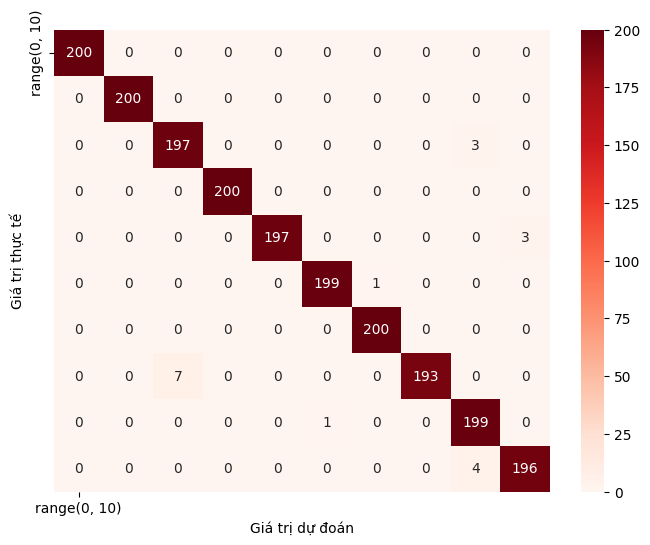

In [11]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=[range(10)], 
            yticklabels=[range(10)])
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()